# pmai-model-context

# Introduction
This notebook uses Hugging Face to train models for automatic image description (image captioning). With libraries such as Transformers, Datasets, and Accelerate

## **Estandar**

1. Codigo se desarrollara en ingles
2. Los prompts en español
3. Usar visualizadores

In [627]:
import importlib
import utils.cache as cache_utils
import utils.model as model_utils
import utils.context as context_utils


#___________________________________________________________________

from utils.decoder import base64_to_image
from utils.decoder import base64_to_image_resized
from utils.local_object import GlobalObjectForContext, context_info
from utils.local_object import GlobalObjectForContext


In [628]:
cache_utils = importlib.reload(cache_utils)
model_utils = importlib.reload(model_utils)
context_utils = importlib.reload(context_utils)


import_Blip_model = model_utils.import_Blip_model
get_quantized_blip_model = model_utils.get_quantized_blip_model
generate_context = context_utils.generate_context



In [629]:
import torch
import time
import os

torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except Exception:
    pass

#### 5 ) **Image Decoding**

In [630]:
processor, blip_model = import_Blip_model()

In [631]:
model_quantized = get_quantized_blip_model(
    blip_model,
    model_name=model_utils.MODEL_ID,
    engine="qnnpack",
    dtype=torch.qint8,
)

In [669]:
from pathlib import Path

image_path = Path("objetos/lakenight.txt")
processor.image_processor.do_resize = True
processor.image_processor.do_center_crop = False

variablexenbase = image_path.read_text(encoding="utf-8").strip()
pil_image = base64_to_image(variablexenbase)

# Calidad maxima: usar modelo base, no cuantizado
contexto, _ = generate_context(pil_image, processor, blip_model)

print(f"contexto: {contexto}")


contexto: A basketball court in the middle of a building with a blue and yellow painted on it


pil_image resized to: (250, 250)


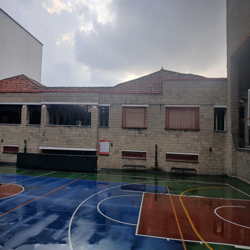

In [670]:
from PIL import Image

try:
    pil_image = pil_image.resize((250, 250))
    print(f"pil_image resized to: {pil_image.size}")
except NameError:
    print("pil_image no está definida. Asegúrate de cargar la imagen antes de redimensionar.")


pil_image


In [ ]:
from pathlib import Path

model_to_use = blip_model


objetos_dir = Path("objetos")
image_files = sorted(objetos_dir.glob("*.txt"))

print(f"Total de imagenes: {len(image_files)}")
print("=" * 80)

for image_file in image_files:
    variablexenbase = image_file.read_text(encoding="utf-8").strip()
    pil_image = base64_to_image(variablexenbase)
    contexto, prompt = generate_context(pil_image, processor, model_to_use)
    print(f"{image_file.stem}: {contexto}")


Total de imagenes: 41
1: A man standing next to a robot that is sitting on top of a piece of luggage
10: A man in a blue shirt standing next to a manne with a stuffed animal on it
11: Two stuffed animals are standing in front of a sign that lac
12: A group of people posing for a photo in front of a red and white wall with a sign that
13: Two people standing next to a robot in front of a sign that' see'
14: A group of people standing in front of a store with a seal mascot and a robot
15: A group of people standing in front of a red and white sign that
16: A group of people posing for a photo in front of a sign that
17: A group of people standing around a robot in a room with a sign that
18: A statue of a humanoid in front of the arch of
19: A robot standing in front of a whiteboard with a blackboard on the wall behind it
2: A woman standing in front of a robot at the entrance to a store with her hands on her hips
20: A white robot standing on top of a red tiled floor next to a man in a 

In [634]:
# Reload context module to apply the latest inference improvements
import importlib
import utils.context as context_utils

context_utils = importlib.reload(context_utils)
generate_context = context_utils.generate_context

# Short quality check to avoid long runs
from pathlib import Path

sample_files = sorted(Path("objetos").glob("*.txt"))[:3]
print(f"Prueba de calidad en {len(sample_files)} imagenes")
print("=" * 90)

for image_file in sample_files:
    base64_txt = image_file.read_text(encoding="utf-8").strip()
    image = base64_to_image(base64_txt)
    caption, _ = generate_context(image, processor, blip_model)
    print(f"{image_file.stem}: {caption}")


Prueba de calidad en 3 imagenes
1: A man standing next to a robot that is sitting on top of a piece of luggage
10: A man in a blue shirt standing next to a manne with a stuffed animal on it
11: Two stuffed animals are standing in front of a sign that lac


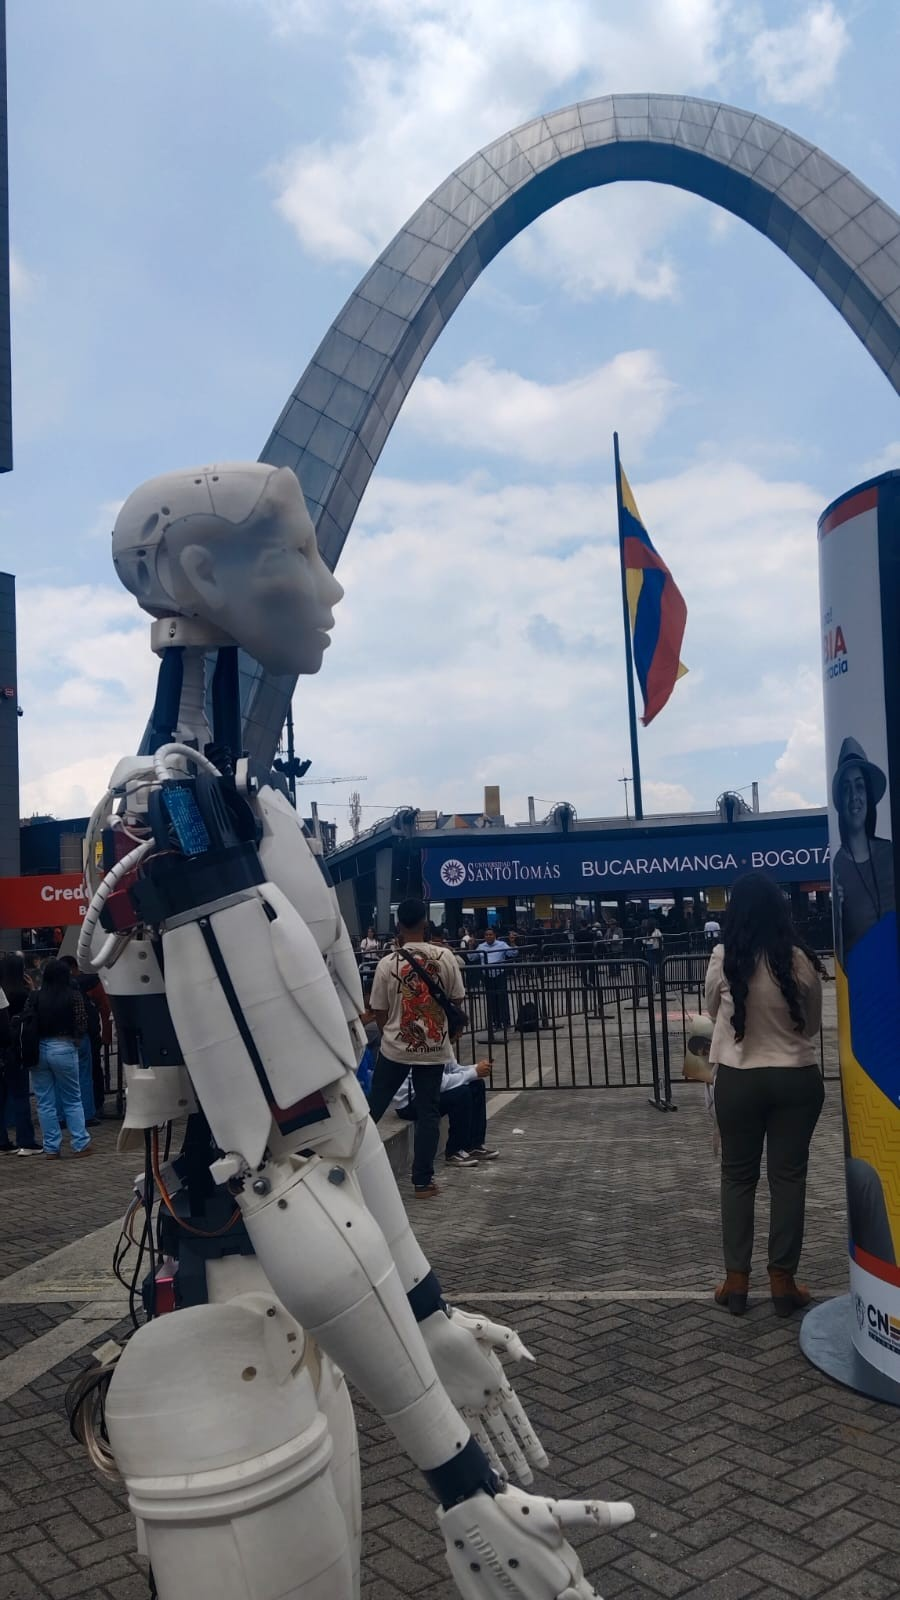

In [639]:
pil_image